# *Prominence*: A discriminator of gravitational wave signals  
## Companion Code for [arXiv:2509.04384](https://arxiv.org/abs/2509.04384)  

### Requirements  
To run this notebook you will need the following Python packages: ```scipy```, ```numpy```, ```pandas```, ```tqdm```, and ```matplotlib```.  
They can be installed via `pip` in the terminal. For example:  

```bash
>> pip install scipy
```

### **Overview**: Provides a worked example for calculating the prominence PDFs and computing the $p$-values, demonstrated for Case (B) of the paper.  



In [1]:
import scipy
from scipy.integrate import simpson
from scipy.signal import find_peaks, peak_prominences, peak_widths
from scipy.interpolate import UnivariateSpline
from scipy.interpolate import interp1d
from scipy.special import zeta
from scipy import integrate
import numpy as np
import pandas as pd
from tqdm import tqdm

import matplotlib
from matplotlib import pyplot as plt
import matplotlib as mpl
from matplotlib import pyplot as plt, ticker as mticker

mpl.rcParams['text.usetex']=True 
mpl.rcParams['text.latex.preamble'] = r'\usepackage{bm}'
plt.rcParams.update({'font.size': 20})
mpl.rcParams["legend.framealpha"] = 1.0
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams["figure.figsize"] = [7.5, 4.5]


In [2]:
# Help function to convert floats into scientfic format in latex
def latex_float(f):
    float_str = "{0:.2g}".format(f)
    if "e" in float_str:
        base, exponent = float_str.split("e")
        return r"{0} \times 10^{{{1}}}".format(base, int(exponent))
    else:
        return float_str


# Load GW sensitivity curves (inside the GW_Data folder). For NANOGrav, the periodogram dataset is loaded

In [3]:
# ---- LISA ----
Data_LISA = pd.read_csv('./GW_Data/LISA.csv',names = ['fpeak', 'Ompeak'],sep=';',decimal=',')
Data_LISA = Data_LISA.loc[Data_LISA['Ompeak'] < 1e-6]
Data_LISA = Data_LISA.sort_values(by=['fpeak'], ascending=True)
LISA_spline = UnivariateSpline(np.log10(Data_LISA['fpeak']), np.log10(Data_LISA['Ompeak']), s=1e-8)

# ---- BBO ----
Data_BBO  = pd.read_csv('./GW_Data/BBO.csv',names = ['fpeak', 'Ompeak'],sep=' ')
Data_BBO = Data_BBO.loc[Data_BBO['Ompeak'] < 1e-6]
Data_BBO = Data_BBO.sort_values(by=['fpeak'], ascending=True)
BB0_spline = UnivariateSpline(np.log10(Data_BBO['fpeak']), np.log10(Data_BBO['Ompeak']), s=1e-8)

# ---- ET ----
Data_ET   = pd.read_csv('./GW_Data/ET.csv',names = ['fpeak', 'Ompeak'],sep=' ')
Data_ET = Data_ET.loc[Data_ET['Ompeak'] < 1e-6]
Data_ET = Data_ET.sort_values(by=['fpeak'], ascending=True)
ET_spline = UnivariateSpline(np.log10(Data_ET['fpeak']), np.log10(Data_ET['Ompeak']), s=1e-8)

# ---- muAres ----
Data_Ares = pd.read_csv('./GW_Data/muAres.csv',names = ['fpeak', 'Ompeak'],sep=';',decimal=',')
Data_Ares = Data_Ares.loc[Data_Ares['Ompeak'] < 1e-6]
Data_Ares = Data_Ares.sort_values(by=['fpeak'], ascending=True)
muAres_spline = UnivariateSpline(np.log10(Data_Ares['fpeak']), np.log10(Data_Ares['Ompeak']), s=1e-6)

# ---- LIGO O5 ----
Data_LIGO = pd.read_csv('./GW_Data/HL.csv',names = ['fpeak', 'Ompeak'],sep=' ')
Data_LIGO = Data_LIGO.loc[Data_LIGO['Ompeak'] < 1e-6]
Data_LIGO = Data_LIGO.sort_values(by=['fpeak'], ascending=True)
LIGO_spline = UnivariateSpline(np.log10(Data_LIGO['fpeak']), np.log10(Data_LIGO['Ompeak']), s=1e-8)

# ---- LVK ----
Data_LVK  = pd.read_csv('./GW_Data/LVK.csv',sep=';',decimal=',',header=None)
Data_LVK.rename({0:'fpeak', 1:'Ompeak'},axis=1,inplace=True) 
Data_LVK.drop_duplicates(subset='fpeak', inplace=True)
Data_LVK = Data_LVK.sort_values(by=['fpeak'], ascending=True)
LVK_spline = UnivariateSpline(np.log10(Data_LVK['fpeak']), np.log10(Data_LVK['Ompeak']), s=1e-8)

# ---- SKA ----
Data_SKA   = pd.read_csv('./GW_Data/SKA.csv',names = ['fpeak', 'Ompeak'],sep=';',decimal=',')
Data_SKA = Data_SKA.loc[Data_SKA['Ompeak'] < 1e-6]
Data_SKA = Data_SKA.sort_values(by=['fpeak'], ascending=True)
SKA_spline = UnivariateSpline(np.log10(Data_SKA['fpeak']), np.log10(Data_SKA['Ompeak']), s=1e-8)

# ---- GAIA ----
Data_GAIA  = pd.read_csv('./GW_Data/GAIA.csv',names = ['fpeak', 'Ompeak'],sep=';',decimal=',')
Data_GAIA = Data_GAIA.loc[Data_GAIA['Ompeak'] < 1e-6]
Data_GAIA = Data_GAIA.sort_values(by=['fpeak'], ascending=True)
GAIA_spline = UnivariateSpline(np.log10(Data_GAIA['fpeak']), np.log10(Data_GAIA['Ompeak']), s=1e-8)

# ---- THEIA ----
Data_THEIA = pd.read_csv('./GW_Data/THEIA.csv',names = ['fpeak', 'Ompeak'],sep=';',decimal=',')
Data_THEIA = Data_THEIA.loc[Data_THEIA['Ompeak'] < 1e-6]
Data_THEIA = Data_THEIA.sort_values(by=['fpeak'], ascending=True)
THEIA_spline = UnivariateSpline(np.log10(Data_THEIA['fpeak']), np.log10(Data_THEIA['Ompeak']), s=1e-8)

# ---- NG15 ----
Data_NG15  = pd.read_csv('./GW_Data/NG15.csv',sep=';',decimal=',',header=None,names=['fpeak', 'Ompeak'])



# Functions for GW NP Signals. 

## In the notebook, we have implementations for:

- First-order phase transitions (FOPTs)
- Domain walls (DWs)
- Cosmic Strings (CSs)
- Scalar-induced Gravitational Waves (SIGWs)


## Usage  
When constructing your own function, the input should be:  
- An array of frequency values $f$ (in Hz)  
- A set of arguments corresponding to the model parameters  

The output should be an array of $h^2 \Omega_\mathrm{GW}$ values with the same length as $f$.  

See some examples below.  


In [4]:
def hOm_FOPT(f, args_model):

    gstar, ξw, βH, α, Tp, κsw, κbc, κmhd = args_model
    
    # Written based on formulas from LISA Cosmology working group (2403.03723)
    
    # -------------------------------------
    # -------- SOUND WAVE SPECTRUM --------
    # -------------------------------------

    n1_sw, n2_sw, n3_sw, a1_sw, a2_sw = 3, 1, -3, 2, 4
    Γ           = 4/3 # adiabatic index. 4/3 for radiation fluid
    cs          = 1/np.sqrt(3)
    ξshell      = np.abs(ξw - cs)
    Δw          = ξshell/max(ξw, cs)
    Hstar_Rstar = (8*np.pi)**(1/3) * max(ξw, cs) * βH**(-1)
    Trh_V       = Tp #Tp*(1 + α)**(1/4)
    H0star      = (1.65 * 10**(-5)) * (gstar/100) ** (1/6) * (Trh_V/100) # Factor to include redshifting to present day (i.e. already has the h^2 prefactor included)
    FGW0        = (1.64 * 10**(-5)) * (100/gstar)**(1/3)                 # Factor to include redshifting to present day (i.e. already has the h^2 prefactor included)
    Asw         = 0.11
    vJ          = (np.sqrt((2/3)*α + α**2) + np.sqrt(1/3))/ (1 + α)

    K           = (0.6*κsw*α)/(1 + α)
    vfsq        = Γ**(-1)*K
    Hstar_τsh   = Hstar_Rstar/np.sqrt(vfsq)
    Hstar_τstar = min(Hstar_τsh, 1)

    # Spectral shape
    def S_SW(f, args):
        n1,n2,n3,a1,a2,f1,f2 = args
        return (f/f1)**n1 * ( 1 + (f/f1)**a1)**((-n1+n2)/(a1))  * ( 1 + (f/f2)**a2 )**((-n2 + n3)/a2)
        
    f1_sw = 0.2 * H0star * (Hstar_Rstar)**(-1)
    f2_sw = 0.5 * H0star * Δw**(-1) * (Hstar_Rstar)**(-1)
    Ωint  = FGW0 * Asw * K**2 * Hstar_τstar * Hstar_Rstar 

    #Integrate spectral shape to get normalisation factor (use a better f)
    ff1 = np.geomspace(1e-10,1000,100_000)
    Sf1  = S_SW(ff1, [n1_sw,n2_sw,n3_sw,a1_sw,a2_sw,f1_sw,f2_sw] )
    lnf1 = np.log(ff1)
    N   = 1/simpson(Sf1, x=lnf1)
    
    # Sound wave amplitude and its peak
    Sf  = S_SW(f, [n1_sw,n2_sw,n3_sw,a1_sw,a2_sw,f1_sw,f2_sw] )
    ΩSW      = N * Ωint * Sf
    
    # -----------------------------------------------
    # ---------- BUBBLE COLLISION SPECTRUM ----------
    # -----------------------------------------------

    n1_bc, n2_bc, a1_bc = 2.4, -2.4, 1.2
    Astr   = 0.05

    Ktilde = κbc*(α/(1 + α))
    Ωp     = FGW0 * Astr * Ktilde**2 * βH**(-2)
    fp     = 0.11 * H0star * βH
    
    # Spectral shape
    def S_BC(f, args):
        n1,n2,a1,fpeak = args
        den  = (n1 - n2)**((n1-n2)/a1)
        num  = ( -n2*(f/fpeak)**(-n1*a1/(n1-n2)) + n1*(f/fpeak)**(-n2*a1/(n1-n2)) )**((n1-n2)/a1)
        return den/num
    
    # Bubble collision amplitude and its peak
    ΩBC      = Ωp * S_BC(f, [n1_bc, n2_bc, a1_bc, fp])
    
    # -----------------------------------------------
    # ------------- TURBULENCE SPECTRUM -------------
    # -----------------------------------------------
    
    n1_mhd, n2_mhd, n3_mhd, a1_mhd, a2_mhd = 3, 1, -8/3, 4, 2.15
    Nn = 2.
    A  = 0.085
    Ωs = κmhd*K # κmhd corresponds to ε in 2403.03723
    vA = (3/4)*Ωs
    f1 = (np.sqrt(3*Ωs))/(2*Nn) * H0star * (Hstar_Rstar)**(-1)
    f2 = 2.2 * H0star * (Hstar_Rstar)**(-1)
    
    # Spectral shape
    def S_MHD(f, args):
        n1,n2,n3,a1,a2,f1,f2 = args
        return (f/f1)**n1 * ( 1 + (f/f1)**a1)**((-n1+n2)/(a1))  * ( 1 + (f/f2)**a2 )**((-n2 + n3)/a2)
    
    #Integrate spectral shape to get normalisation factor
    f   = np.geomspace(1e-10, 1e10, 200)  # Should be between -inf to +inf. Putting big/small numbers is numerically, the same thing
    Sf  = S_MHD(f, [n1_mhd,n2_mhd,n3_mhd,a1_mhd,a2_mhd,f1,f2])
    lnf = np.log(f)
    N   = 1/simps(Sf, lnf)
    
    # Magnetohydrodinamics contribution
    ΩMHD = N * ((3 * A * vA * Ωs**2 * Hstar_Rstar**2)/(4 * np.pi**2 * Nn)) * FGW0 * Sf
    
    # Get peak amplitude and frequency from full spectra
    hOm_Total = ΩSW + ΩBC + ΩMHD
    
    return hOm_Total

def hOm_DomainWall(f, args_model):

    E, Vbias, b, c = args_model
    
    a         = 3
    eGW       = 0.7 # 0.7±0.4
    gstar     = 106.75 # SM High-T DOFs
    A         = 0.8 # 0.8 ± 0.1/ area parameter
    Cann      = 5 # Assuming Z2 breaking
    hOm_peak  = 1.49e-10 * (eGW/0.7) * (A/0.8)**4 * (10.75/gstar)**(1/3) * (E**(1/3)/1e7)**(12) * (1e7/Vbias)**2
    f_peak    = 5.93e-6 * (5/Cann)**(1/2)*(0.8/A)**(1/2)*(1e7/E**(1/3))**(3/2)*(Vbias/1e7)**(1/2)
    S         = lambda x: ((a+b)**c)/(b*x**(-a/c) + a*x**(b/c))**c
    
    hOm_Total = hOm_peak*S(f/f_peak)
    
    return hOm_Total

def hOm_CosmicString(f, args_model):

    G_mu, C, match_feq = args_model
    
    # Analytical formulas from 2312.10455
    
    fyr            = 32*1e-9
    Gamma          = 50
    u_k            = lambda k: (2.89/(2*k))*(f/fyr)*(Gamma/50)*(G_mu/1e-11)
    Sum_k1         = sum( (1/((1 + 2.075*u_k(k))**(1.945))) * ( k**(-17/6)/zeta(17/6) ) for k in range(1,25)  ) 

    hOm_PTA_PowerL = 4.2e-9 * (f/fyr)**(3/2) * (Gamma/50) * (G_mu/(1e-11))**2 * 1
    hOm_PTA        = hOm_PTA_PowerL * Sum_k1
    hOm_Total      = hOm_PTA
        
    if (f > match_feq):
        hOm_Laser = 4.78e-5*C*np.sqrt(G_mu)
        hOm_Total += hOm_Laser

    return hOm_Total

def hOm_PhaseInf(f, args_model):

    logA, logfc, alpha, beta = args_model
    
    A  = 10**logA
    fc = 10**logfc
    hOm_Total = A*(alpha + beta)/(beta*(f/fc)**(-alpha) + alpha*(f/fc)**beta)
    
    return hOm_Total


# Functions for astrophysical backgrounds

In [5]:
# Extra-galatic background
def hOm_ExtGW(f, args_model):

    log10_h2Ext, alpha = args_model
    
    hOmExt = 10**log10_h2Ext
    
    return hOmExt*(f/(1e-3))**(alpha)

# Galatic background
def hOm_GalGW(f, args_model):

    log10_h2Gal, ns = args_model
    
    Tobs   = 4
    year   = 1
    a1     = -0.15
    b1     = -2.72
    ak     = -0.37
    bk     = -2.49
    v      = 1.56
    f2     = 6.7e-4
    hOmGal = 10**(log10_h2Gal)
    f1     = 10**( a1*np.log10(Tobs/year) + b1 )
    fknee  = 10**( ak*np.log10(Tobs/year) + bk )
    hOm    = (f**3/2)*(f/1)**(-ns)*(1 + np.tanh( (fknee - f)/f2 ) )*np.exp( -(f/f1)**v )*hOmGal
    
    return hOm

# Supermassive black hole binaries at PTAs
def hOm_SMBHBs(f, args_model):

    gw_bhb = args_model
    
    # Values used by PTArcade/Nanograv collab.
    Tspan  = 505861299.1401643
    fyr    = 3.168808781402895e-08
    H_0_Hz = 2.1842852410855023e-18
    h      = 0.674
    
    h2Omega = (2*np.pi**2*(10**gw_bhb[0])**2)/(3*H_0_Hz**2) * \
              (f/(fyr**(1)))**(5-gw_bhb[1]) * (fyr**(2))

    return h2Omega


# Setting Up the Signals  

## Options  
You can either:  
- Use analytical expressions for the spectral shape, or  
- Provide a tabular dataset  

## Important Notes  
- Ensure that the frequency range is consistent for the signals (**i.e.**, all signals must be defined in the same frequency range). Later, when generating the backgrounds, ensure that the frequency range is also identical.
- Note that the prominence calculation also depends on the chosen frequency window.  


>  <font size="3"> In case you want to use tabular datasets (I will be loading 4 datasets: 2 FOPT signals and 2 DW signals) </font>

In [6]:
# Data should be in tabular format. Collumn with "freq" for frequency and "h2Om" for GW amplitude in energy density units
# Data should be comma separated. If not, the sep argument below should be changed to match your dataset
# As example, we read the data from Signal_Data
Data_DW1   = pd.read_csv('./Signal_Data/FOPT_1.csv', sep=',')
Data_DW2   = pd.read_csv('./Signal_Data/FOPT_2.csv', sep=',')
Data_FOPT1 = pd.read_csv('./Signal_Data/DW_1.csv', sep=',')
Data_FOPT2 = pd.read_csv('./Signal_Data/DW_2.csv', sep=',')

# Your data should have the following structure
Data_DW1

,freq,h2Om
0,1.000000e-07,3.195751e-17
1,1.001612e-07,3.211228e-17
2,1.003226e-07,3.226780e-17
3,1.004843e-07,3.242407e-17
4,1.006463e-07,3.258110e-17
...,...,...
14995,3.073297e+03,1.379519e-31
14996,3.078250e+03,1.372871e-31
14997,3.083212e+03,1.366254e-31
14998,3.088181e+03,1.359669e-31


In [7]:
# Save the frequency and amplitude intro variables
# Note that the frequency array is the same for all files in the dataset
freq_window = np.array(Data_DW1['freq'])
f_max       = freq_window.max() # Getting the max frenquency (to be used later during plotting)


hOm_Signal1A = np.array(Data_DW1['h2Om'])
hOm_Signal1B = np.array(Data_DW2['h2Om'])
hOm_Signal2A = np.array(Data_FOPT1['h2Om'])
hOm_Signal2B = np.array(Data_FOPT2['h2Om'])


>  <font size="3"> In case you want to use analytical expressions </font>

In [8]:
# As an example, we consider double peak FOPT/DW signals
gstar1, ξw1, βH1, α1, Tp1, κsw1, κbc1 = 106.75, 1, 50, 1.80, 37.98, 1, 0
gstar2, ξw2, βH2, α2, Tp2, κsw2, κbc2 = 106.75, 1, 50, 1.80, 1770.81, 1, 0
args_PT1                              = [ gstar1, ξw1, βH1, α1, Tp1, κsw1, κbc1 ]
args_PT2                              = [ gstar2, ξw2, βH2, α2, Tp2, κsw2, κbc2 ]

E1, Vbias1, b1, c1                    = 10**24.03, 10**12.49, 0.75, 1.65
E2, Vbias2, b2, c2                    = 10**27.36, 10**19.15, 0.75, 1.65
args_DW1                              = [ E1, Vbias1, b1, c1 ]
args_DW2                              = [ E2, Vbias2, b2, c2 ]

# Compute the two signals to compare
# Window between 10^(-7) and maximum ET frequency
f_max                                 = Data_ET['fpeak'].max()
freq_window                           = np.geomspace(1e-7, f_max, 15_000)
hOm_Signal1A                          = hOm_FOPT(freq_window, args_PT1)
hOm_Signal1B                          = hOm_DomainWall(freq_window, args_DW1)
hOm_Signal2A                          = hOm_FOPT(freq_window, args_PT2)
hOm_Signal2B                          = hOm_DomainWall(freq_window, args_DW2)


# Setting up miscellaneous options

In [9]:
# Number of points to generate the histograms. Recommended close to 1M points. For testing purposes, 50k will give reasonable results
N_points = 50_000

# Error. It will be used to determine the bin-width. The default it is 1%
perc     = 0.01

# Set up lists for the prominence. **Should not be changed!!**
prom_signal1_list = []
prom_signal2_list = []


# Main loop for the calculation of the *Prominence* PDFs

In [10]:
# Starting main loop
for idx in tqdm(range(0, N_points)): #
    
    # Calculate background distribution based on priors
    log10_h2Ext    = np.random.normal(loc=-12.38, scale=0.17, size=None)   # Extra galatic background (normalisation)
    alphaExt       = np.random.uniform(0.66-0.34,0.66+0.34)                # Extra galatic background (tilt)
    log10_h2Gal    = np.random.normal(loc=-7.85, scale=0.21, size=None)    # Galatic background (normalisation)   
    alphaGal       = np.random.uniform((7/3)-0.055, (7/3)+0.015)           # Galatic background (tilt)   

    # Summing all backgrounds
    BackVary       = hOm_ExtGW(freq_window,[log10_h2Ext,alphaExt]) + hOm_GalGW(freq_window,[log10_h2Gal,alphaGal])

    # Summing our signals to the background (taking log10 so prominence has order 1 numbers)
    Sig_plus_bck_1 = np.log10( hOm_Signal1A + hOm_Signal2B + BackVary )
    Sig_plus_bck_2 = np.log10( hOm_Signal2A + hOm_Signal1B + BackVary )
    
    # Get prominences (first signal)
    peaks1, _      = find_peaks(Sig_plus_bck_1)                  # Find the peaks
    prominences1   = peak_prominences(Sig_plus_bck_1, peaks1)[0] # Compute prominences. First element is the prominence, second/third the left/right bases
    prominences1   = -np.sort(-prominences1)                     # sort prominences (first largest and second smallest)    

    # Get prominences (second signal)
    peaks2, _      = find_peaks(Sig_plus_bck_2)                  # Find the peaks
    prominences2   = peak_prominences(Sig_plus_bck_2, peaks2)[0] # Compute prominences. First element is the prominence, second/third the left/right bases
    prominences2   = -np.sort(-prominences2)                     # sort prominences (first largest and second smallest)    
    
    # "prominences" is an array with N elements (depending on the number of peaks)
    # Append prominences to a list
    prom_signal1_list.append(prominences1)
    prom_signal2_list.append(prominences2)


100%|████████████████████████████████████| 50000/50000 [01:17<00:00, 643.18it/s]


In [11]:
# Some data preprocessing. 
# Depending on the background parameters, you can have 1, 2 or more peaks. Which means each entry can have different size 
# To standardize the list, we create placeholder prominences with zero value

# Signal 1
maximum = 0
for l in prom_signal1_list:
   maximum = max(maximum, len(l))
for l in prom_signal1_list:
    l.resize(maximum,refcheck=False)
Data_pandas1 = pd.DataFrame()
for i in range(int(maximum)):
    list_arrays = [s[i] for s in prom_signal1_list]
    Data_pandas1.insert(i, "{}".format(i), list_arrays)

Signal1_sum = Data_pandas1.stack().reset_index(drop=True)  # Create a global array with all prominences
plt_range1  = (Signal1_sum.values.min(), Signal1_sum.values.max())


# Signal 2
maximum = 0
for l in prom_signal2_list:
   maximum = max(maximum, len(l))
for l in prom_signal2_list:
    l.resize(maximum,refcheck=False)
Data_pandas2 = pd.DataFrame()
for i in range(int(maximum)):
    list_arrays = [s[i] for s in prom_signal2_list]
    Data_pandas2.insert(i, "{}".format(i), list_arrays)

Signal2_sum = Data_pandas2.stack().reset_index(drop=True)  # Create a global array with all prominences
plt_range2  = (Signal2_sum.values.min(), Signal2_sum.values.max())

# Dropping the zero prominences
Signal1_sum = Signal1_sum.loc[np.where(Signal1_sum > 0.1)]
Signal2_sum = Signal2_sum.loc[np.where(Signal2_sum > 0.1)]

# Choose number of bins based on the uncertainty
n_bins  = int( min( 
                  (Signal1_sum.max() - Signal1_sum.min())/(perc*Signal1_sum.max()),
                  (Signal2_sum.max() - Signal2_sum.min())/(perc*Signal2_sum.max())
                 )
             )
if n_bins == 0:
    n_bins = 1

# We want to compare the shapes of the distributions, so the magnitude of the prominence should not play a role
# To do that, we normalise the prominence distributions between 0 and 1, and compute the p-vals on those
normalized_Sig1             = (Signal1_sum - min(Signal1_sum))/(max(Signal1_sum) - min(Signal1_sum))
normalized_Sig2             = (Signal2_sum - min(Signal2_sum))/(max(Signal2_sum) - min(Signal2_sum))
counts_Sig1, bin_edges_Sig1 = np.histogram(normalized_Sig1, bins=n_bins, density=True,range=(0,1))
counts_Sig2, bin_edges_Sig2 = np.histogram(normalized_Sig2, bins=n_bins, density=True,range=(0,1))


# Quick plotting of the *Prominence* PDFs

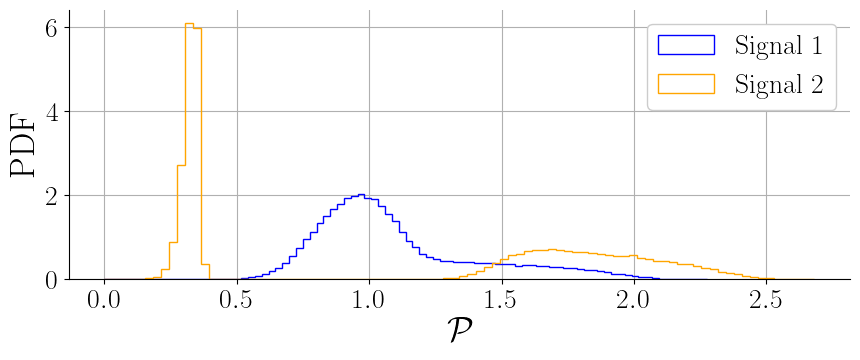

In [12]:
# Let us make some cool plots
fig, axs = plt.subplots(1, 1, figsize=(9, 4), tight_layout=True)

##### Histograms (density=True to normalise integral to 1)
SIGSUM_1 = Signal1_sum.hist(bins=n_bins, density=True, color='blue',   histtype = 'step', ax=axs, range=plt_range1, label=r'$\mathrm{Signal~1}$')
SIGSUM_2 = Signal2_sum.hist(bins=n_bins, density=True, color='orange', histtype = 'step', ax=axs, range=plt_range2, label=r'$\mathrm{Signal~2}$')
plt.legend()
plt.xlabel(r'$\mathcal{P}$',fontsize=25)
plt.ylabel(r'$\mathrm{PDF}$',fontsize=25)
plt.tight_layout()
plt.savefig('./Plots/Prominence_PDF.pdf',dpi=125.)
plt.show()


# Computation of the $p-$values

>  <font size="5"> Kolmogorov-Smirnov (KS) test </font>
<p>
    
<font size="3"> Since we want to use the histograms themselves (and not the entire dataset), we can not use the ```scipy``` native functions. Instead, we first manually calculate the cumulative distribution functions (CDFs) of each signal, and then use the internal ```scipy``` scripts to compute this </font>


In [13]:
# Now we compute the p-values
# Since I want to give the histograms as input, instead of raw data, the default scipy code can not be used
# as the cdf's come out wrong. Instead, we manually compute the CDF ourselves and then use their code to compute it
# To get their code, check scipy docs. 

############ KS-test p-val ############
data1 = np.cumsum(counts_Sig1)/np.sum(counts_Sig1) 
data2 = np.cumsum(counts_Sig2)/np.sum(counts_Sig2) 
c1 = np.arange(1, len(data1)+1) / len(data1)
c2 = np.arange(1, len(data2)+1) / len(data2)


<font size="3"> Quickly plotting the CDF functions to see if they make sense </font>




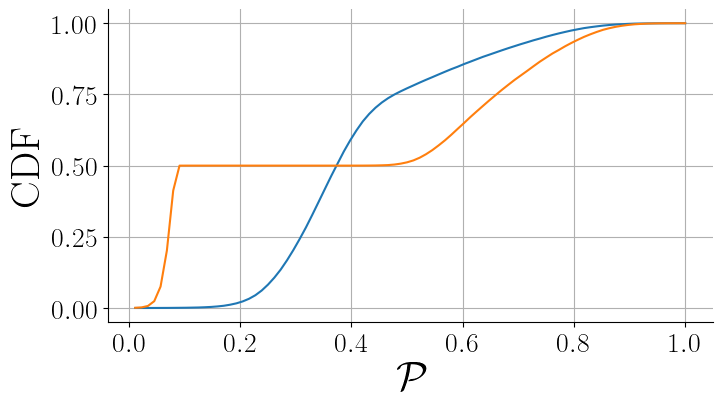

In [14]:
plt.plot(c1,data1)
plt.plot(c2,data2)
plt.ylabel(r'$\mathrm{CDF}$', fontsize=30)
plt.xlabel(r'$\mathcal{P}$', fontsize=30)
plt.grid()
plt.tight_layout()
plt.savefig('./Plots/Prominence_CDF.pdf',dpi=125.)
plt.show()


In [15]:
# KS-test p-val (code from scipy)
n1 = data1.shape[0]
n2 = data2.shape[0]

data_all = np.concatenate([data1, data2])
# using searchsorted solves equal data problem
cdf1 = np.searchsorted(data1, data_all, side='right') / n1
cdf2 = np.searchsorted(data2, data_all, side='right') / n2
cddiffs = data1 - data2


m, n = sorted([float(n1), float(n2)], reverse=True)
en = m * n / (m + n)
d = np.max( (np.abs(cddiffs.min()), np.abs(cddiffs.max())) )
p_value_KS = scipy.stats.distributions.kstwo.sf(d, np.round(en))
print("========================================")
print("p-val (KS-test) = {}".format(p_value_KS))
print("========================================")

p-val (KS-test) = 1.1560760720292087e-10


>  <font size="5"> Cramér–von Mises (CvM) test </font>


In [16]:
############ CVM-test p-val ############
xa = np.cumsum(counts_Sig1)/np.sum(counts_Sig1)
ya = np.cumsum(counts_Sig2)/np.sum(counts_Sig2)
nx = len(xa)
ny = len(ya)

# get ranks of x and y in the pooled sample
z = np.concatenate([xa, ya])
# in case of ties, use midrank (see [1])
r = scipy.stats.rankdata(z, method='average')
rx = r[:nx]
ry = r[nx:]

# compute U (eq. 10 in [2])
u = nx * np.sum((rx - np.arange(1, nx+1))**2)
u += ny * np.sum((ry - np.arange(1, ny+1))**2)

# compute T (eq. 9 in [2])
k, N1 = nx*ny, nx + ny
t = u / (k*N1) - (4*k - 1)/(6*N1)

# compute expected value and variance of T (eq. 11 and 14 in [2])
et = (1 + 1/N1)/6
vt = (N1+1) * (4*k*N1 - 3*(nx**2 + ny**2) - 2*k)
vt = vt / (45 * N1**2 * 4 * k)

# computed the normalized statistic (eq. 15 in [2])
tn = 1/6 + (t - et) / np.sqrt(45 * vt)

# approximate distribution of tn with limiting distribution
# of the one-sample test statistic
# if tn < 0.003, the _cdf_cvm_inf(tn) < 1.28*1e-18, return 1.0 directly
if tn < 0.003:
    p_value_CVM = 1.0
else:
    p_value_CVM = max(0, 1. - scipy.stats._hypotests._cdf_cvm_inf(tn))

print("=======================================")
print("p-val (CvM-test) = {}".format(p_value_CVM))
print("=======================================")

p-val (CvM-test) = 0.00482863068697581


# Final global plot

/home/mrazi09/anaconda3/envs/GravWaves/lib/python3.7/site-packages/ipykernel_launcher.py:58: PeakPropertyWarning: some peaks have a prominence of 0


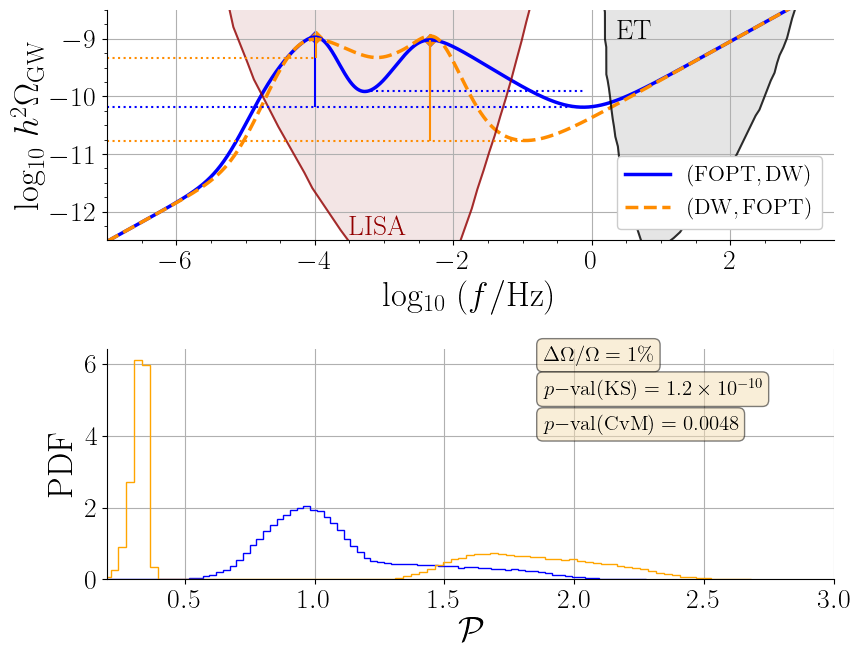

In [17]:
# Let us make some cool final plot
fig, axs = plt.subplots(2, 1, figsize=(9, 7), tight_layout=True)

##### Histograms (density=True to normalise integral to 1)
SIGSUM_PT = Signal1_sum.hist(bins=n_bins, density=True, color='blue',   histtype = 'step', ax=axs[1], range=plt_range1)
SIGSUM_DW = Signal2_sum.hist(bins=n_bins, density=True, color='orange', histtype = 'step', ax=axs[1], range=plt_range2)

##### Legend and axes for the histogram plot
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
axs[1].text(0.60, 0.95, r'$\Delta\Omega/\Omega = {}\%$'.format(int(perc*100)),transform=axs[1].transAxes, bbox=props, fontsize=15)
axs[1].text(0.60, 0.80, '$p$$-$$\mathrm{{val}} (\mathrm{{KS}}) = {a}$'.format(a=latex_float(p_value_KS)), transform=axs[1].transAxes, bbox=props, fontsize=15)
axs[1].text(0.60, 0.65, '$p$$-$$\mathrm{{val}} (\mathrm{{CvM}}) = {a}$'.format(a=latex_float(p_value_CVM)), transform=axs[1].transAxes, bbox=props, fontsize=15)
axs[1].set_xlabel(r'$\mathcal{P}$', fontsize=25)  
axs[1].set_ylabel(r'$\mathrm{PDF}$', fontsize=25)

##### x-axis limits
axs[1].set_xlim(0.2,3.0)

##### SGWB spectrum (backgroud parameters are fixed to their central values)
log10_h2Gal  = -7.85
log10_h2Ext  = -12.38
alphaExt     = 2/3
alphaGal     = 7/3
Back         = hOm_ExtGW(freq_window,[log10_h2Ext,alphaExt]) + hOm_GalGW(freq_window,[log10_h2Gal,alphaGal])

##### GW curves
Om_Full1 = np.log10(hOm_Signal1A + hOm_Signal2B + Back)
Om_Full2 = np.log10(hOm_Signal2A + hOm_Signal1B + Back)
axs[0].plot(np.log10(freq_window), Om_Full1 ,'-',  color='blue',       linewidth=2.5, label=r'$\mathrm{(FOPT,DW)}$')
axs[0].plot(np.log10(freq_window), Om_Full2 ,'--', color='darkorange', linewidth=2.5, label=r'$\mathrm{(DW,FOPT)}$')
axs[0].legend(fontsize=16,loc='lower right')

##### GW experiments
fpeak  = [np.log10(Data_LISA['fpeak']),np.log10(Data_ET['fpeak'])]
Ompeak = [np.log10(Data_LISA['Ompeak']),np.log10(Data_ET['Ompeak'])]
labels = [r'$\mathrm{LISA}$',r'$\mathrm{ET}$']
colors = ['#920000','black']

for a in zip(fpeak,Ompeak,labels,colors):
    axs[0].plot(a[0], a[1], '-',label=a[2], color=a[3], rasterized=True, alpha=0.8)
    axs[0].fill_between(a[0], a[1], 1e-4*np.ones(len(a[0])), alpha=0.1, color=a[3], rasterized=True)
axs[0].text(x=-3.5,y=-12.4,s=r"$\mathrm{LISA}$",color='#920000')
axs[0].text(x=0.37,y=-9.0,s=r"$\mathrm{ET}$",color='black')

##### Prominence lines
peaks1, _        = find_peaks(Om_Full1)
prominences_Sig1 = peak_prominences(Om_Full1, peaks1)[0]
contour_heights  = Om_Full1[peaks1] - prominences_Sig1
axs[0].scatter(np.log10(freq_window)[peaks1],Om_Full1[peaks1],marker='D',color='blue')
axs[0].vlines(x=np.log10(freq_window)[peaks1], ymin=contour_heights, ymax=Om_Full1[peaks1],color='blue',linestyle='solid',zorder=100)
axs[0].hlines(y=contour_heights,xmin=np.log10(freq_window)[peak_prominences(Om_Full1, peaks1)[1]], xmax=np.log10(freq_window)[peak_prominences(Om_Full1, peaks1)[2]], color='blue',linestyle=':', alpha=1,linewidth=1.5)    

peaks2, _        = find_peaks(Om_Full2)
prominences_Sig2 = peak_prominences(Om_Full2, peaks2)[0]
contour_heights  = Om_Full2[peaks2] - prominences_Sig2
axs[0].scatter(np.log10(freq_window)[peaks2],Om_Full1[peaks2],marker='D',color='darkorange')
axs[0].vlines(x=np.log10(freq_window)[peaks2], ymin=contour_heights, ymax=Om_Full1[peaks2],color='darkorange',linestyle='solid',zorder=100)
axs[0].hlines(y=contour_heights,xmin=np.log10(freq_window)[peak_prominences(Om_Full2, peaks2)[1]], xmax=np.log10(freq_window)[peak_prominences(Om_Full2, peaks1)[2]], color='darkorange',linestyle=':', alpha=1,linewidth=1.5)    

##### Axis labels and grid
axs[0].set_ylim(-12.5,-8.5)
axs[0].set_xlim(np.log10(1e-7), np.log10(f_max))
axs[0].set_xlabel(r'$\mathrm{log_{10}}~(f/\mathrm{Hz})$',fontsize=25)
axs[0].set_ylabel(r'$\mathrm{log_{10}}~h^2 \Omega_\mathrm{GW}$',fontsize=25)
axs[0].grid()

##### Extra ticks
axs[0].xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(4))
axs[0].yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(4))

plt.savefig('./Plots/Case_B.pdf',dpi=125.)
plt.show()

